# Trend Analysis — Superstore Dataset
**Minggu 7 — Hari Senin | Simulasi Industri Junior Data Analyst**

**Tujuan:** Menganalisis tren waktu, pola musiman, dan pertumbuhan penjualan pada dataset Sample Superstore (2014–2017).

**Cakupan analisis:**
1. Tren waktu (line chart)
2. Pertumbuhan kumulatif & komposisi kategori (area chart)
3. Pola musiman (seasonal pattern)
4. Pertumbuhan tahunan (growth analysis)

## 1. Import Library & Load Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

COLOR_BLUE = '#2E5EAA'
COLOR_ORANGE = '#E8813A'
COLOR_LIGHT = '#9FC5E8'
COLOR_GRID = '#E5E5E5'

df = pd.read_csv('Sample_-_Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M')

print(f"Jumlah baris: {df.shape[0]:,}")
print(f"Rentang tanggal: {df['Order Date'].min().date()} s.d. {df['Order Date'].max().date()}")
df.head()

Jumlah baris: 9,994
Rentang tanggal: 2014-01-03 s.d. 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


## 2. Agregasi Data Bulanan & Tahunan

In [2]:
monthly = (
    df.groupby('YearMonth')
    .agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum'), Orders=('Order ID', 'nunique'))
    .reset_index()
)
monthly['YearMonth_dt'] = monthly['YearMonth'].dt.to_timestamp()
monthly['Cumulative_Sales'] = monthly['Sales'].cumsum()

yearly = df.groupby('Year').agg(Sales=('Sales', 'sum'), Profit=('Profit', 'sum')).reset_index()
yearly['Sales_Growth_%'] = yearly['Sales'].pct_change() * 100
yearly['Profit_Growth_%'] = yearly['Profit'].pct_change() * 100

seasonal = df.groupby('Month').agg(Sales=('Sales', 'mean')).reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 'Jul', 'Agu', 'Sep', 'Okt', 'Nov', 'Des']
seasonal['MonthName'] = month_names

yearly

,Year,Sales,Profit,Sales_Growth_%,Profit_Growth_%
0,2014,484247.4981,49543.9741,NaN,NaN
1,2015,470532.5090,61618.6037,-2.832227,24.371540
2,2016,609205.5980,81795.1743,29.471521,32.744284
3,2017,733215.2552,93439.2696,20.355962,14.235675


## 3. Tren Waktu — Line Chart

Line chart menampilkan penjualan bulanan sepanjang 2014–2017 beserta garis tren linear untuk melihat arah pergerakan jangka panjang.

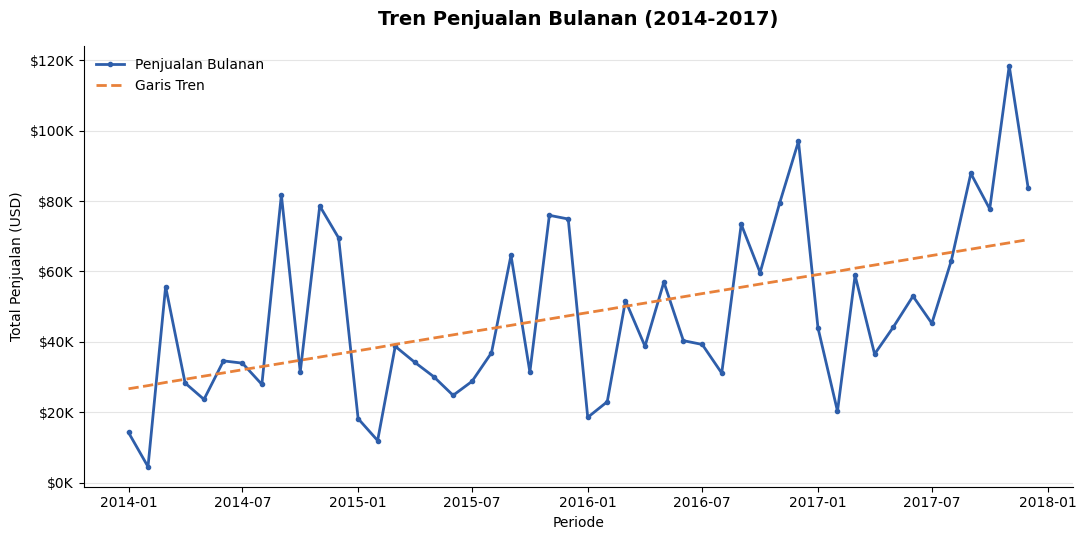

In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(monthly['YearMonth_dt'], monthly['Sales'], color=COLOR_BLUE, linewidth=2,
        marker='o', markersize=3, label='Penjualan Bulanan')

z = np.polyfit(range(len(monthly)), monthly['Sales'], 1)
trend = np.poly1d(z)(range(len(monthly)))
ax.plot(monthly['YearMonth_dt'], trend, color=COLOR_ORANGE, linewidth=2, linestyle='--', label='Garis Tren')

ax.set_title('Tren Penjualan Bulanan (2014-2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode')
ax.set_ylabel('Total Penjualan (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
ax.legend(loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

**Insight:**
- Garis tren menunjukkan arah **naik (positif)** dari 2014 ke 2017 meskipun data bulanan cukup fluktuatif.
- Penjualan tertinggi terjadi pada **November 2017** dan penjualan terendah pada **Februari 2014**.
- Terlihat lonjakan berulang menjelang akhir tahun (September–Desember) — mengindikasikan pola musiman.

## 4. Pertumbuhan Kumulatif — Area Chart

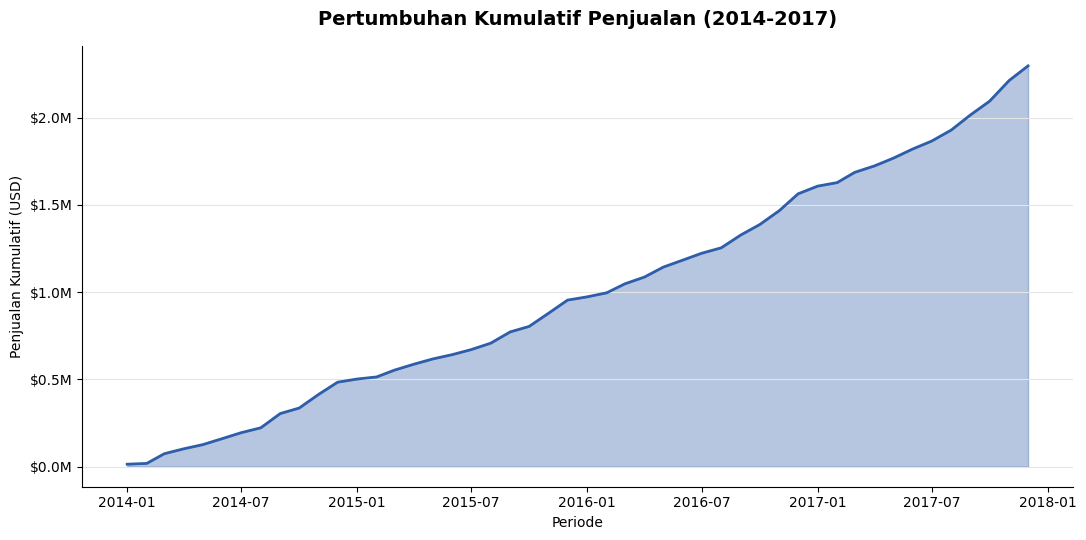

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.fill_between(monthly['YearMonth_dt'], monthly['Cumulative_Sales'], color=COLOR_BLUE, alpha=0.35)
ax.plot(monthly['YearMonth_dt'], monthly['Cumulative_Sales'], color=COLOR_BLUE, linewidth=2)
ax.set_title('Pertumbuhan Kumulatif Penjualan (2014-2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Periode')
ax.set_ylabel('Penjualan Kumulatif (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
plt.tight_layout()
plt.show()

**Insight:** Kurva kumulatif semakin curam di paruh kedua periode (2016–2017), menandakan **percepatan pertumbuhan penjualan**, bukan sekadar pertumbuhan linear.

## 5. Komposisi Penjualan per Kategori — Stacked Area Chart

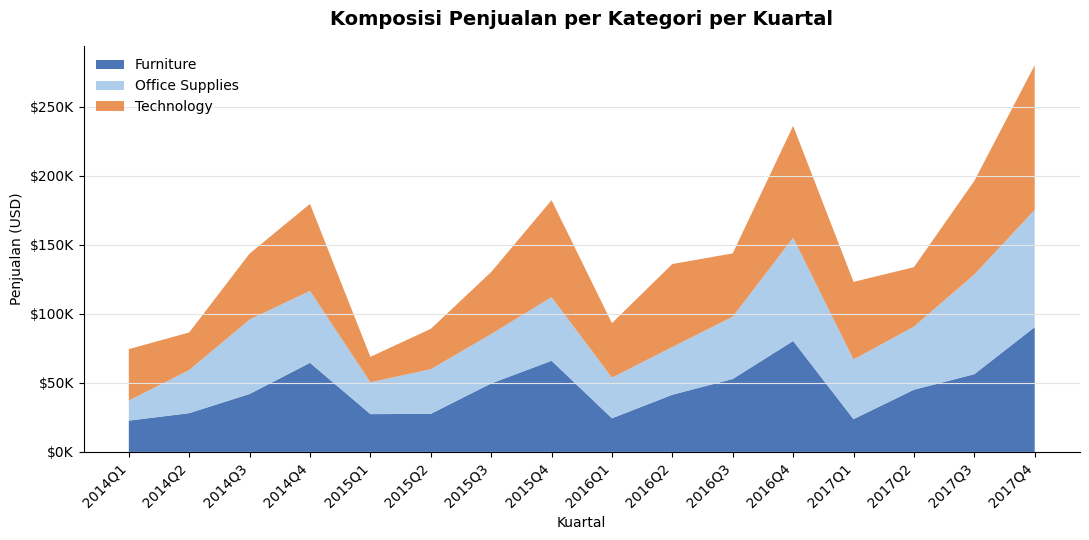

In [5]:
df['YQ'] = df['Order Date'].dt.to_period('Q').astype(str)
cat_q = df.groupby(['YQ', 'Category'])['Sales'].sum().unstack().fillna(0)

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.stackplot(cat_q.index, cat_q['Furniture'], cat_q['Office Supplies'], cat_q['Technology'],
             labels=['Furniture', 'Office Supplies', 'Technology'],
             colors=[COLOR_BLUE, COLOR_LIGHT, COLOR_ORANGE], alpha=0.85)
ax.set_title('Komposisi Penjualan per Kategori per Kuartal', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kuartal')
ax.set_ylabel('Penjualan (USD)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
plt.xticks(rotation=45, ha='right')
ax.legend(loc='upper left', frameon=False)
ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
plt.tight_layout()
plt.show()

**Insight:**
- **Technology** memberi kontribusi terbesar pada lonjakan Q4 tiap tahun.
- **Furniture** relatif stabil namun juga ikut naik menjelang akhir tahun.
- Ketiga kategori bergerak searah — kenaikan Q4 bukan didorong satu kategori saja, tapi seluruh lini produk.

## 6. Pola Musiman — Rata-rata Penjualan per Bulan

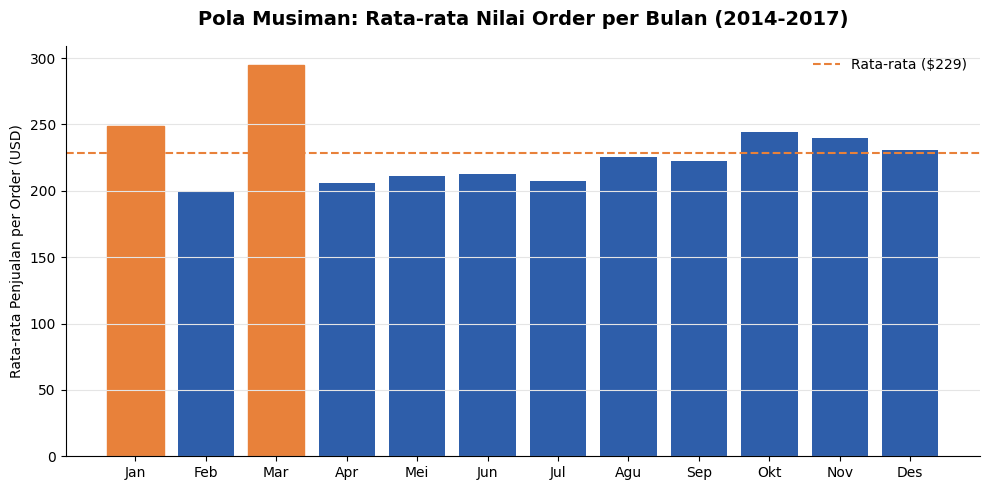

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(seasonal['MonthName'], seasonal['Sales'], color=COLOR_BLUE)
avg_line = seasonal['Sales'].mean()
ax.axhline(avg_line, color=COLOR_ORANGE, linestyle='--', linewidth=1.5, label=f'Rata-rata (${avg_line:.0f})')

peak_idx = seasonal['Sales'].nlargest(2).index
for i in peak_idx:
    bars[i].set_color(COLOR_ORANGE)

ax.set_title('Pola Musiman: Rata-rata Nilai Order per Bulan (2014-2017)', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Rata-rata Penjualan per Order (USD)')
ax.legend(frameon=False)
ax.grid(axis='y', color=COLOR_GRID, linewidth=0.8)
plt.tight_layout()
plt.show()

**Insight:**
- Bulan dengan **rata-rata nilai order tertinggi**: Maret, Januari, dan Oktober.
- Bulan dengan rata-rata terendah: Februari — konsisten dengan pola pasca-liburan yang lambat.
- Musiman lebih terlihat dari *total* penjualan bulanan (grafik line chart) yang melonjak di Q4, meski rata-rata nilai per order relatif merata sepanjang tahun — artinya lonjakan Q4 didorong oleh **volume order yang lebih banyak**, bukan nilai order yang lebih besar.

## 7. Pertumbuhan Tahunan (Year-over-Year)

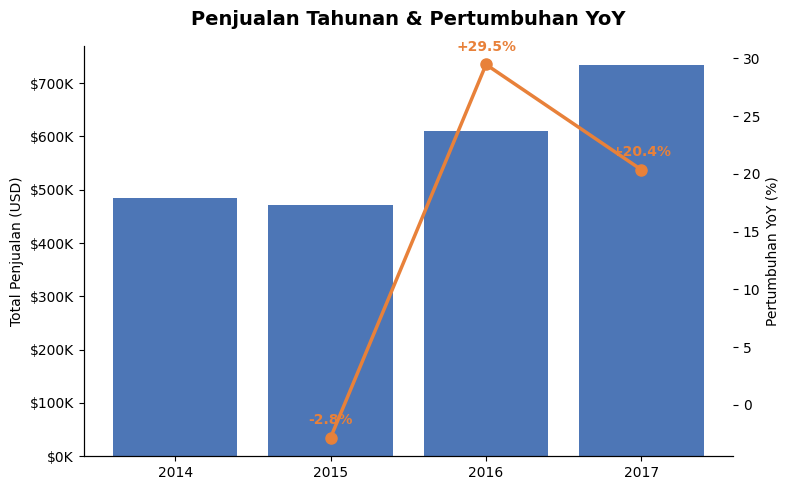

,Year,Sales,Profit,Sales_Growth_%,Profit_Growth_%
0,2014,484247.4981,49543.9741,NaN,NaN
1,2015,470532.5090,61618.6037,-2.832227,24.371540
2,2016,609205.5980,81795.1743,29.471521,32.744284
3,2017,733215.2552,93439.2696,20.355962,14.235675


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
years = yearly['Year'].astype(str)

ax.bar(years, yearly['Sales'], color=COLOR_BLUE, alpha=0.85)
ax2 = ax.twinx()
ax2.plot(years, yearly['Sales_Growth_%'], color=COLOR_ORANGE, marker='o', linewidth=2.5, markersize=8)

for i, (y, g) in enumerate(zip(years, yearly['Sales_Growth_%'])):
    if pd.notna(g):
        ax2.annotate(f'{g:+.1f}%', (i, g), textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=10, fontweight='bold', color=COLOR_ORANGE)

ax.set_title('Penjualan Tahunan & Pertumbuhan YoY', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Total Penjualan (USD)')
ax2.set_ylabel('Pertumbuhan YoY (%)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
ax2.spines['top'].set_visible(False)
plt.tight_layout()
plt.show()

yearly

**Insight:**
- 2015 sempat **turun tipis -2.8%** dibanding 2014.
- 2016 rebound kuat dengan pertumbuhan **+29.5%**, dan profit tumbuh **+32.7%** — tahun paling sehat dari sisi margin.
- 2017 tumbuh **+20.4%** dalam penjualan, tapi pertumbuhan profit melambat ke **+14.2%** — mengindikasikan margin sedikit tertekan, kemungkinan akibat diskon atau biaya yang naik lebih cepat dari penjualan.

## 8. Ringkasan Analisis Tren

| Aspek | Temuan |
|---|---|
| **Tren Waktu** | Tren jangka panjang positif; penjualan tumbuh dari ~$484K (2014) menjadi ~$733K (2017) |
| **Musiman** | Lonjakan konsisten setiap Q4 (Sep–Des), terutama di kategori Technology |
| **Pertumbuhan** | Rata-rata pertumbuhan tahunan +15.7%; 2016 adalah tahun terbaik dari sisi profit |
| **Perhatian** | Pertumbuhan profit 2017 melambat dibanding penjualan — perlu ditelusuri lebih lanjut (kemungkinan terkait diskon) |

**Rekomendasi awal:**
1. Siapkan stok dan kapasitas operasional ekstra menjelang **Q4**, khususnya kategori Technology.
2. Investigasi kebijakan diskon di 2017 karena margin tumbuh lebih lambat dari penjualan.
3. Gunakan Februari sebagai fokus kampanye promosi karena merupakan bulan terlemah secara historis.